In [11]:
import os
import re
import seaborn as sns
import json
import mne
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np

In [12]:
eeg_eeg_json = '/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-*/ses-*/eeg/*_eeg.json'

json_files = glob.glob(eeg_eeg_json)

In [13]:
eeg_data = []

for json_file in json_files:
    # Open and read the JSON file
    with open(json_file, 'r') as f:
        data = json.load(f)
        
        # Extract relevant information
        eeg_info = {
            'file': json_file,  # Store the filename for reference
            'TaskName': data.get('TaskName', None),
            'EEGChannelCount': data.get('EEGChannelCount', None),
            'RecordingDuration': data.get('RecordingDuration', None),
            'SamplingFrequency': data.get('SamplingFrequency', None)
        }
        eeg_data.append(eeg_info)

eeg_df = pd.DataFrame(eeg_data)


print(eeg_df.head())
eeg_df.shape


                                                file        TaskName  \
0  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
1  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
2  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
3  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
4  /Users/Ethan/Desktop/Machine learning download...  MusicListening   

   EEGChannelCount  RecordingDuration  SamplingFrequency  
0              129            139.496               1000  
1              129            123.147               1000  
2              129            124.914               1000  
3              129            134.580               1000  
4              129            121.464               1000  


(240, 5)

In [14]:

file_path = "/Users/Ethan/Desktop/Machine learning downloads/ds003774/stimuli/Behavioural_data.csv"  # Adjust if needed
df_behav = pd.read_csv(file_path, sep=',')
df_behav.describe()

,Subject,Song_ID,Enjoyment,Familiarity
count,240.000000,240.000000,240.000000,240.000000
mean,10.500000,6.500000,2.679167,3.587500
std,5.778332,3.459267,1.109668,1.196513
min,1.000000,1.000000,1.000000,1.000000
25%,5.750000,3.750000,2.000000,3.000000
50%,10.500000,6.500000,3.000000,4.000000
75%,15.250000,9.250000,3.000000,5.000000
max,20.000000,12.000000,5.000000,5.000000


In [15]:
events_data_path = '/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-*/ses-*/eeg/*_events.tsv'
events_files = glob.glob(events_data_path)

events_data = []

for file in events_files:

    parts = file.split(os.sep)  
    subject_id = parts[-4]  
    session_id = parts[-3]  

    df = pd.read_csv(file, sep='\t')


    df['subject_id'] = subject_id
    df['session_id'] = session_id

    events_data.append(df)

events_combined_df = pd.concat(events_data, ignore_index=True)

events_combined_df = events_combined_df.dropna(axis=1, how='all')
events_combined_df = events_combined_df.dropna(subset=['onset', 'duration'])

print(f"Shape of events_combined_df: {events_combined_df.shape}")
print(events_combined_df.head())

print(events_combined_df[['subject_id', 'session_id']].value_counts())

events_combined_df = events_combined_df.groupby(['subject_id', 'session_id']).head(128)
print(f"New shape after trimming: {events_combined_df.shape}")


Shape of events_combined_df: (30768, 6)
      onset  duration    sample value subject_id session_id
0  0.334866    1000.0  334.8662  SESS    sub-019     ses-10
1  0.543867    1000.0  543.8673  CELL    sub-019     ses-10
2  0.651863    1000.0  651.8631  CELL    sub-019     ses-10
3  0.755866    1000.0  755.8657  CELL    sub-019     ses-10
4  0.859868    1000.0  859.8684  CELL    sub-019     ses-10
subject_id  session_id
sub-010     ses-04        132
            ses-03        132
            ses-02        132
            ses-01        132
            ses-08        132
                         ... 
sub-020     ses-08        128
            ses-09        128
            ses-10        128
            ses-11        128
            ses-12        128
Name: count, Length: 240, dtype: int64
New shape after trimming: (30720, 6)


/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3329/10999452.py:3: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3329/10999452.py:3: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3329/10999452.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=True)


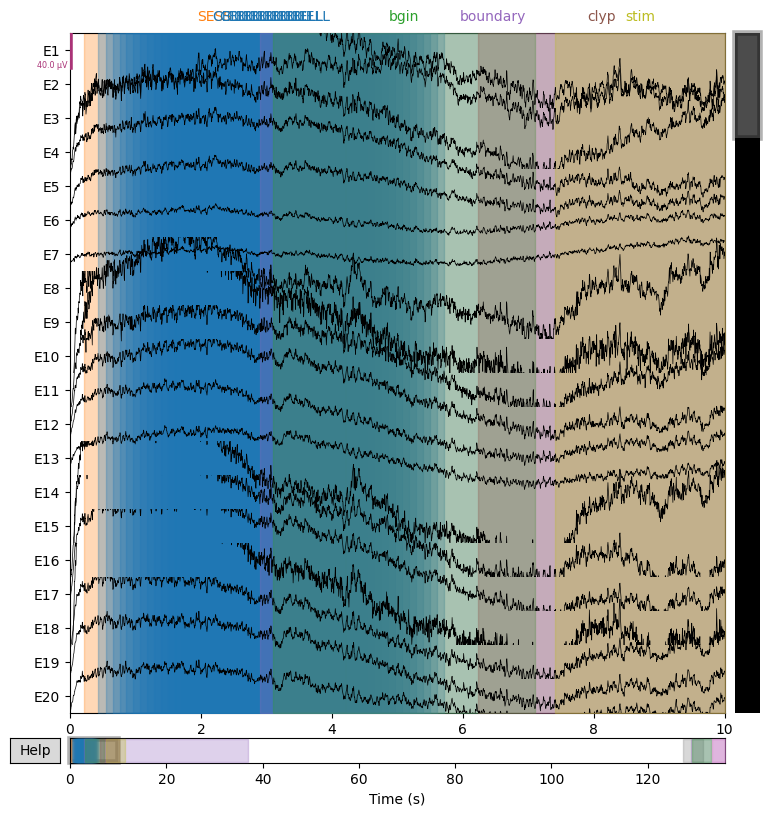

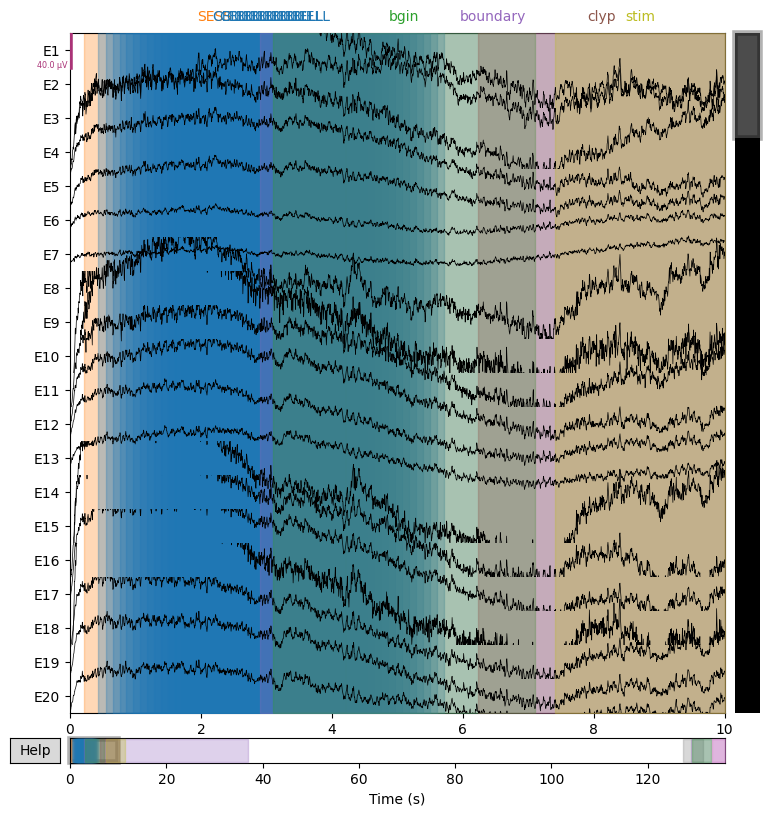

In [16]:

set_file = "/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set"

raw = mne.io.read_raw_eeglab(set_file, preload=True)
raw.plot()


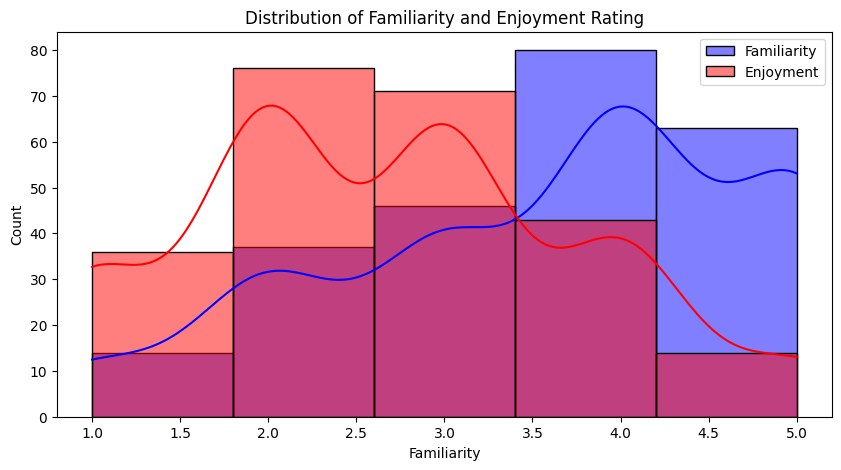

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df_behav['Familiarity'], bins=5, kde=True,label="Familiarity",color="blue")
sns.histplot(df_behav['Enjoyment'], bins=5, kde=True,label="Enjoyment",color="red")
plt.legend()
plt.title('Distribution of Familiarity and Enjoyment Rating')
plt.show()

In [18]:
#Assuming json_files has paths of the JSON files
subject_ids = [file.split(os.sep)[-3] for file in json_files]  # Extract subject_id from file path
session_ids = [file.split(os.sep)[-2] for file in json_files]  # Extract session_id from file path

# Add the subject_id and session_id to the eeg_df
eeg_df['subject_id'] = subject_ids
eeg_df['session_id'] = session_ids

In [19]:
print(events_combined_df[['subject_id', 'session_id']])

eeg_df['subject_id'] = eeg_df['file'].apply(lambda x: re.search(r'sub-(\d+)', x).group(1))
eeg_df['session_id'] = eeg_df['file'].apply(lambda x: re.search(r'ses-(\d+)', x).group(1))

eeg_df['subject_id'] = eeg_df['subject_id'].astype(int)
eeg_df['session_id'] = eeg_df['session_id'].apply(lambda x: f"ses-{int(x):02d}")  # Format as ses-01, ses-02, etc.

print(eeg_df.head())



      subject_id session_id
0        sub-019     ses-10
1        sub-019     ses-10
2        sub-019     ses-10
3        sub-019     ses-10
4        sub-019     ses-10
...          ...        ...
30763    sub-007     ses-07
30764    sub-007     ses-07
30765    sub-007     ses-07
30766    sub-007     ses-07
30767    sub-007     ses-07

[30720 rows x 2 columns]
                                                file        TaskName  \
0  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
1  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
2  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
3  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
4  /Users/Ethan/Desktop/Machine learning download...  MusicListening   

   EEGChannelCount  RecordingDuration  SamplingFrequency  subject_id  \
0              129            139.496               1000          19   
1              129            123.147               1000     

In [20]:
eeg_df['subject_id'] = eeg_df['file'].apply(lambda x: re.search(r'sub-(\d+)', x).group(1))
eeg_df['session_id'] = eeg_df['file'].apply(lambda x: re.search(r'ses-(\d+)', x).group(1))

# Convert to match behavioural data format
eeg_df['subject_id'] = eeg_df['subject_id'].astype(int)
eeg_df['session_id'] = eeg_df['session_id'].apply(lambda x: f"ses-{int(x):02d}")  # Format as ses-01, ses-02, etc.

print(eeg_df.head())


                                                file        TaskName  \
0  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
1  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
2  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
3  /Users/Ethan/Desktop/Machine learning download...  MusicListening   
4  /Users/Ethan/Desktop/Machine learning download...  MusicListening   

   EEGChannelCount  RecordingDuration  SamplingFrequency  subject_id  \
0              129            139.496               1000          19   
1              129            123.147               1000          19   
2              129            124.914               1000          19   
3              129            134.580               1000          19   
4              129            121.464               1000          19   

  session_id  
0     ses-10  
1     ses-11  
2     ses-02  
3     ses-05  
4     ses-04  


In [21]:
# Load the behavioural data
behavioural_df = pd.read_csv("/Users/Ethan/Desktop/Machine learning downloads/ds003774/stimuli/behavioural_data_with_sessions.csv")  

behavioural_df.rename(columns={'Session': 'session_id'}, inplace=True)

# Ensure subject_id follows the same naming convention
behavioural_df.rename(columns={'Subject': 'subject_id'}, inplace=True)

# Ensure session_id follows "ses-XX" format
behavioural_df['session_id'] = behavioural_df['session_id'].apply(lambda x: f"ses-{int(x.split('-')[-1]):02d}")

# Display the cleaned dataframe
print(behavioural_df.head())




   subject_id  Song_ID  Enjoyment  Familiarity session_id
0           1        1          2            2     ses-01
1           1        2          3            2     ses-02
2           1        3          3            3     ses-03
3           1        4          2            2     ses-04
4           1        5          2            2     ses-05
